In [1]:
import os
import numpy as np
import scipy.io as sio
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
from utils import plot_sq

In [ ]:
datadir = "/data/users4/xli/MSIVA/MSIVA/results/sim_iter150_v20k_snr1k"
ss_list = ['s1','s2','s3','s4','s5']
num_ss = len(ss_list)
data1_loss = np.zeros((3, num_ss, num_ss))

for i, ss in enumerate(ss_list):
    for j, tss in enumerate(ss_list):
        ss_dir = f"gt_{ss}_test_{tss}"
        J = sio.loadmat(os.path.join(datadir, ss_dir, "J.mat"))
        data1_loss[0,i,j] = np.squeeze(J["J_um"])
        data1_loss[1,i,j] = np.squeeze(J["J_ummm"])
        data1_loss[2,i,j] = np.squeeze(J["J_mm"])

In [ ]:
num_iter = 150
num_combopt = 11
isi_um = np.zeros((num_ss, num_ss, num_combopt))
isi_ummm = np.zeros((num_ss, num_ss, num_combopt))
isi_mm = np.zeros((num_ss, num_ss, num_combopt))
aux_um = np.zeros((num_ss, num_ss, num_combopt))
aux_ummm = np.zeros((num_ss,num_ss,num_combopt))
aux_mm = np.zeros((num_ss,num_ss,num_combopt))

for i, ss in enumerate(ss_list):
    for j, tss in enumerate(ss_list):
        if tss == 's5':
            num_combopt = 1
        else:
            num_combopt = 11
        
        ss_dir = f"gt_{ss}_test_{tss}"
        isi = sio.loadmat(os.path.join(datadir, ss_dir, "isi.mat"))
        aux = sio.loadmat(os.path.join(datadir, ss_dir, "aux.mat"))

        isi_um[i,j,:] = np.squeeze(isi["isi_um"])
        if tss == 's5':
            aux_um[i,j,:] = np.squeeze(aux[f'aux_um'][2,:])
        else:
            a = np.squeeze(aux[f'aux_um'][1,:])
            aux_um[i,j,:] = np.array([a[k][0][0] for k in range(num_combopt)])
        
        isi_ummm[i,j,:] = np.squeeze(isi["isi_ummm"])
        if tss == 's5':
            aux_ummm[i,j,:] = np.squeeze(aux[f'aux_ummm'][2,:])
        else:
            a = np.squeeze(aux[f'aux_ummm'][1,:])
            aux_ummm[i,j,:] = np.array([a[k][0][0] for k in range(num_combopt)])
        
        isi_mm[i,j,:] = np.squeeze(isi["isi_mm"])
        if tss == 's5':
            aux_mm[i,j,:] = np.squeeze(aux[f'aux_mm'][2,:])
        else:
            a = np.squeeze(aux[f'aux_mm'][1,:])
            aux_mm[i,j,:] = np.array([a[k][0][0] for k in range(num_combopt)])

isi_um_min = np.min(isi_um, axis=2)
isi_ummm_min = np.min(isi_ummm, axis=2)
isi_mm_min = np.min(isi_mm, axis=2)

isi_um_min_ind = np.argmin(isi_um, axis=2)
isi_ummm_min_ind = np.argmin(isi_ummm, axis=2)
isi_mm_min_ind = np.argmin(isi_mm, axis=2)

aux_um_min = np.min(aux_um, axis=2)
aux_ummm_min = np.min(aux_ummm, axis=2)
aux_mm_min = np.min(aux_mm, axis=2)

aux_um_min_ind = np.argmin(aux_um, axis=2)
aux_ummm_min_ind = np.argmin(aux_ummm, axis=2)
aux_mm_min_ind = np.argmin(aux_mm, axis=2)

# use loss to get ISI
isi_um_min_loss = np.zeros((num_ss, num_ss))
isi_ummm_min_loss = np.zeros((num_ss, num_ss))
isi_mm_min_loss = np.zeros((num_ss, num_ss))

for i in range(num_ss):
    for j in range(num_ss):
        isi_um_min_loss[i, j] = isi_um[i, j, aux_um_min_ind[i, j]]
        isi_ummm_min_loss[i, j] = isi_ummm[i, j, aux_ummm_min_ind[i, j]]
        isi_mm_min_loss[i, j] = isi_mm[i, j, aux_mm_min_ind[i, j]]

misi = np.stack((isi_um_min_loss, isi_ummm_min_loss, isi_mm_min_loss), axis=0)

/tmp/ipykernel_2029530/3651441525.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  aux_um[i,j,:] = np.squeeze(aux[f'aux_um'][2,:])
/tmp/ipykernel_2029530/3651441525.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  aux_ummm[i,j,:] = np.squeeze(aux[f'aux_ummm'][2,:])
/tmp/ipykernel_2029530/3651441525.py:37: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  aux_mm[i,j,:] = np.squeeze(aux[f'aux_mm'][2,:])


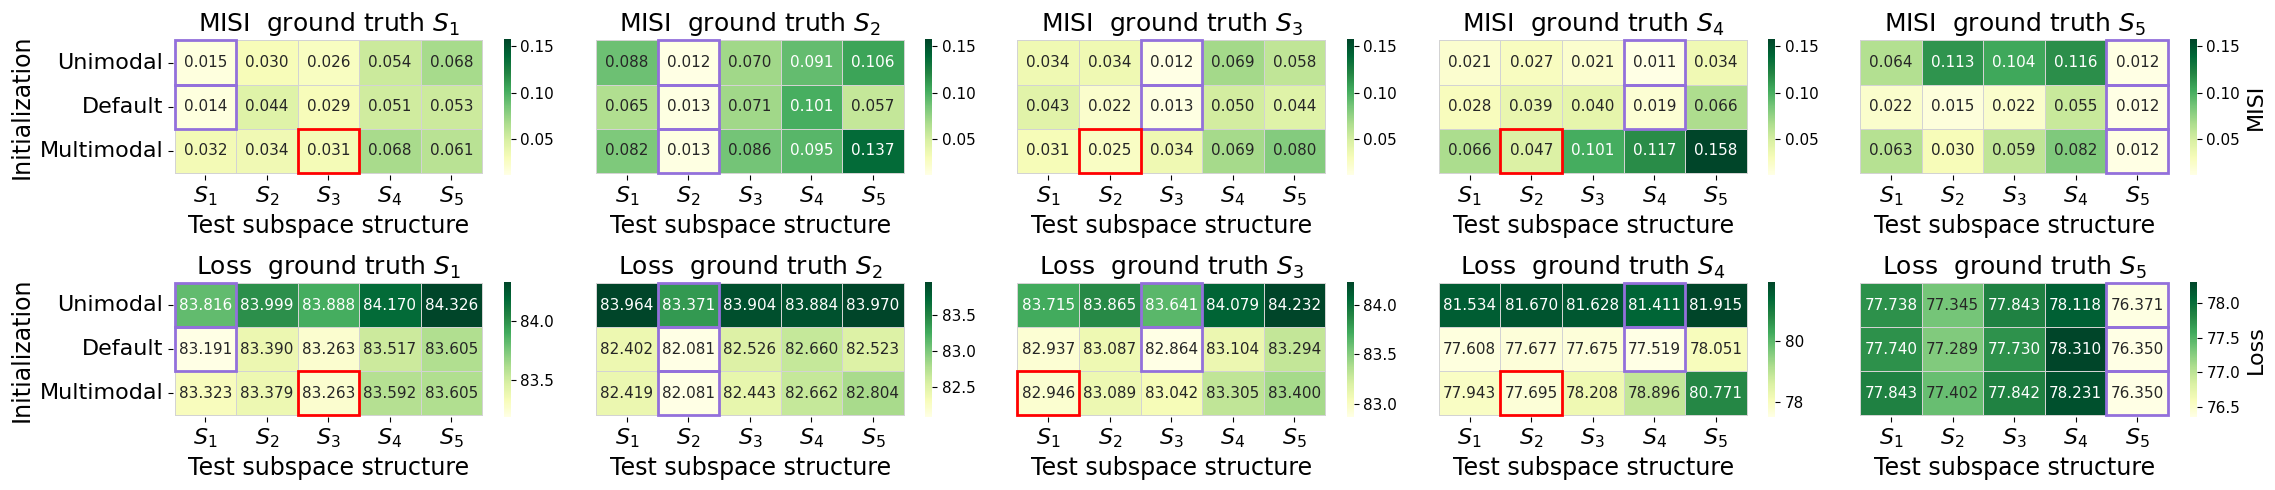

In [ ]:
ss_labels = ["$S_1$", "$S_2$", "$S_3$", "$S_4$", "$S_5$"]
init_labels = ["Unimodal", "Default", "Multimodal"]
metric_labels = ["MISI", "Loss"]
data_list = [misi, data1_loss]
fig, axes = plt.subplots(2, 5, figsize=(4.6*5, 5))
delta = 0.025

for i in range(5):
    for j in range(2):
        ax = axes[j,i]
        data = data_list[j][:,i,:]
        if j == 0:
            dmax = misi.max()
            dmin = misi.min()
        else:
            dmax = data.max()
            dmin = data.min()
        if i == 0:
            heatmap = sns.heatmap(data,vmin=dmin,vmax=dmax,cmap="YlGn",annot=True,fmt=".3f",xticklabels=ss_labels,yticklabels=init_labels,linewidths=0.5,linecolor='lightgray',ax=ax,annot_kws={"size": 11})#magma_r
            ax.set_ylabel("Initialization", fontsize=17)
        else:
            heatmap = sns.heatmap(data,vmin=dmin,vmax=dmax,cmap="YlGn",annot=True,fmt=".3f",xticklabels=ss_labels,yticklabels=False,linewidths=0.5,linecolor='lightgray',ax=ax,annot_kws={"size": 11})
        ax.set_title(f"{metric_labels[j]}  ground truth {ss_labels[i]}", fontsize=18)
        ax.set_xlabel("Test subspace structure", fontsize=17)
        ax.tick_params(axis='both', which='major', labelsize=16)
        ax.set_xlim(0-delta,5+delta*1.5)
        ax.set_ylim(3+delta*1.5,0-delta)
        for k in range(3):
            min_ind = np.argmin(data[k,:])
            c = "mediumpurple" if min_ind == i else "red"
            square = plt.Rectangle((min_ind, k), 1, 1, fill=False, ec=c, linewidth=2, zorder=1)
            ax.add_patch(square)
        cbar = heatmap.collections[0].colorbar
        if i == 4:
            cbar.set_label(f"{metric_labels[j]}", fontsize=16)
        cbar.ax.tick_params(labelsize=11)

plt.tight_layout()
plt.savefig(f"figures/simulation_misi_loss.pdf")

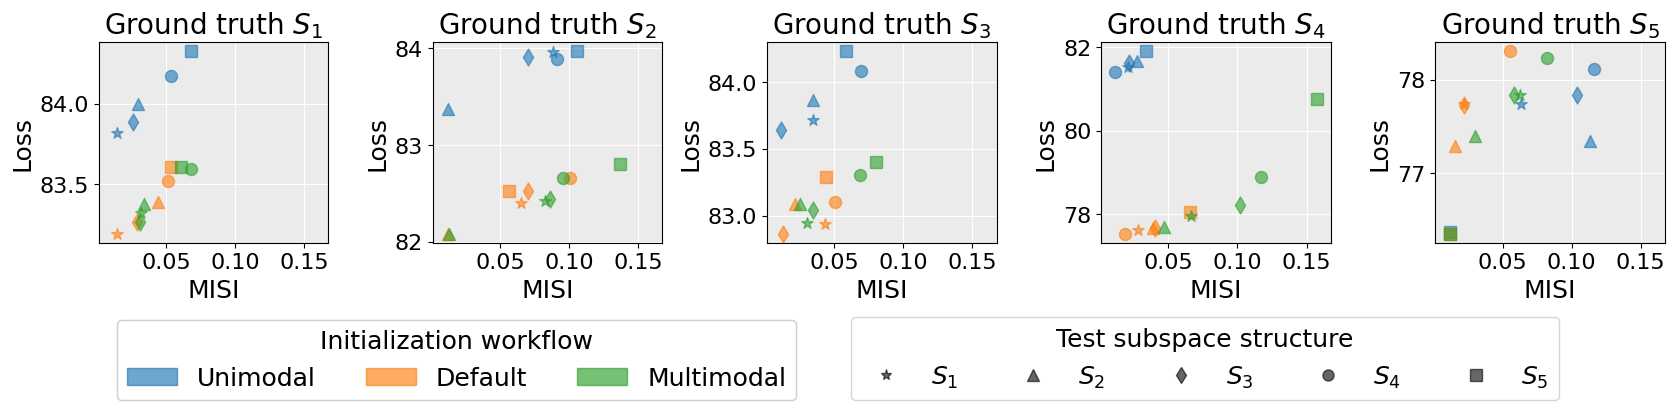

In [ ]:
markers = ["*", "^", "d", "o", "s"]
colors = ["C0", "C1", "C2"]

color_handles = [
    mpatches.Patch(color=c, label=label, alpha=0.6)
    for c, label in zip(colors, init_labels)
]

marker_handles = [
    mlines.Line2D([], [], color="black", marker=m, linestyle="None",
                  markersize=8, label=label, alpha=0.6)
    for m, label in zip(markers, ss_labels)
]

fig, axes = plt.subplots(1, 5, figsize=(17, 3.8))
for j in range(5):
    ax = axes[j]
    for i in range(3):
        for k in range(5):
            ax.scatter(
                misi[i, j, k], data1_loss[i, j, k],
                s=75, marker=markers[k], alpha=0.6, c=colors[i]
            )
    ax.set_xlabel("MISI", fontsize=18)
    ax.set_ylabel("Loss", fontsize=18)
    ax.set_title(f"Ground truth {ss_labels[j]}", fontsize=20)
    ax.tick_params(axis="both", which="major", labelsize=16)
    ax.set_xlim(misi.min() - 0.01, misi.max() + 0.01)
    ax.set_facecolor("#EBEBEB")          # gray background
    ax.grid(color="white", linewidth=0.8) # white grid lines
    ax.set_axisbelow(True)               # grid behind the data points

leg1 = fig.legend(
    handles=color_handles,
    title="Initialization workflow",
    loc="lower center",
    bbox_to_anchor=(0.28, -0.1),
    ncol=3,
    fontsize=18,
    title_fontsize=18,
    frameon=True,
)
leg2 = fig.legend(
    handles=marker_handles,
    title="Test subspace structure",
    loc="lower center",
    bbox_to_anchor=(0.72, -0.1),
    ncol=5,
    fontsize=18,
    title_fontsize=18,
    frameon=True,
)
fig.add_artist(leg1)  # re-add leg1 since fig.legend() replaces it

plt.tight_layout(rect=[0, 0.15, 1, 1])  # leave bottom space for legends
plt.savefig("figures/simulation_misi_vs_loss.pdf", bbox_inches="tight")

In [6]:
corr = np.zeros((num_ss, 8, 12, 12))

for i,ss in enumerate(ss_list):
    ss_dir=f"gt_{ss}_test_{ss}"
    data=sio.loadmat(os.path.join(datadir,ss_dir,"Agt.mat"))
    A=np.squeeze(data['A'])
    
    data=sio.loadmat(os.path.join(datadir,ss_dir,"Wgt.mat"))
    W=np.squeeze(data['W'])

    data=sio.loadmat(os.path.join(datadir,ss_dir,"Wtest.mat"))
    W1=np.squeeze(data['W_um'])
    W2=np.squeeze(data['W_ummm'])
    W3=np.squeeze(data['W_mm'])

    corr[i,0] = W1[0]@A[0]
    corr[i,1] = W1[1]@A[1]
    corr[i,2] = W2[0]@A[0]
    corr[i,3] = W2[1]@A[1]
    corr[i,4] = W3[0]@A[0]
    corr[i,5] = W3[1]@A[1]
    corr[i,6] = W[0]@A[0]
    corr[i,7] = W[1]@A[1]

In [7]:
corr_sorted = np.copy(corr)
corr_sorted[0,0] = corr[0,0][:,[0,1,2,3,4,5,6,7,8,9,11,10]]
corr_sorted[1,0] = corr[1,0][:,[4,5,6,7,2,3,0,1,8,9,11,10]]
corr_sorted[2,0] = corr[2,0][:,[3,4,5,0,1,2,6,7,8,9,10,11]]
corr_sorted[3,0] = corr[3,0][:,[0,1,2,3,4,5,6,7,9,8,11,10]]
corr_sorted[4,0] = corr[4,0][:,np.argmax(np.abs(corr[4,0]),axis=1)]

corr_sorted[0,1] = corr[0,1][:,[0,1,2,3,4,5,6,7,8,10,11,9]]
corr_sorted[1,1] = corr[1,1][:,[4,5,6,7,2,3,0,1,8,9,11,10]]
corr_sorted[2,1] = corr[2,1][:,[3,4,5,0,1,2,6,7,8,10,11,9]]
corr_sorted[3,1] = corr[3,1][:,[0,1,2,3,4,5,6,7,9,11,8,10]]
corr_sorted[4,1] = corr[4,1][:,np.argmax(np.abs(corr[4,1]),axis=1)]

corr_sorted[0,2] = corr[0,2][:,[0,1,2,3,4,5,6,7,8,9,11,10]]
corr_sorted[1,2] = corr[1,2][:,[6,7,2,3,0,1,4,5,8,9,11,10]]
corr_sorted[2,2] = corr[2,2][:,[6,7,8,3,4,5,0,1,2,9,10,11]]
corr_sorted[3,2] = corr[3,2][:,[4,5,6,7,0,1,2,3,9,11,10,8]]
corr_sorted[4,2] = corr[4,2][:,np.argmax(np.abs(corr[4,2]),axis=1)]

corr_sorted[0,3] = corr[0,3][:,[0,1,2,3,4,5,6,7,8,9,10,11]]
corr_sorted[1,3] = corr[1,3][:,[6,7,2,3,0,1,4,5,8,9,11,10]]
corr_sorted[2,3] = corr[2,3][:,[6,7,8,3,4,5,0,1,2,11,10,9]]
corr_sorted[3,3] = corr[3,3][:,[4,5,6,7,0,1,2,3,8,10,9,11]]
corr_sorted[4,3] = corr[4,3][:,np.argmax(np.abs(corr[4,3]),axis=1)]

corr_sorted[0,4] = corr[0,4][:,[0,1,6,7,8,2,3,4,5,10,11,9]]
corr_sorted[1,4] = corr[1,4][:,[0,1,2,3,8,9,6,7,4,5,11,10]]
corr_sorted[2,4] = corr[2,4][:,[3,4,5,6,7,8,0,1,2,11,9,10]]
corr_sorted[3,4] = corr[3,4][:,[0,1,2,3,4,5,6,7,11,9,8,10]]
corr_sorted[4,4] = corr[4,4][:,np.argmax(np.abs(corr[4,4]),axis=1)]

corr_sorted[0,5] = corr[0,5][:,[0,1,6,7,8,2,3,4,5,9,11,10]]
corr_sorted[1,5] = corr[1,5][:,[0,1,2,3,8,9,6,7,4,5,10,11]]
corr_sorted[2,5] = corr[2,5][:,[3,4,5,6,7,8,0,1,2,11,9,10]]
corr_sorted[3,5] = corr[3,5][:,[0,1,2,3,4,5,6,7,11,8,9,10]]
corr_sorted[4,5] = corr[4,5][:,np.argmax(np.abs(corr[4,5]),axis=1)]

In [8]:
corrabsmax = np.max(np.abs(corr))
val = 1 #corrabsmax
num_source = 12

# S1
num_unique_source = 3
s1 = np.zeros((num_source, num_source))
s1[:2,:2] = val
s1[2:5,2:5] = val
s1[5:9,5:9] = val
s1[9,9] = val
s1[10,10] = val
s1[11,11] = val

# S2
num_unique_source = 2
s2 = np.zeros((num_source, num_source))
s2[:2,:2] = val
s2[2:4,2:4] = val
s2[4:6,4:6] = val
s2[6:8,6:8] = val
s2[8:10,8:10] = val
s2[10,10] = val
s2[11,11] = val

# S3
num_unique_source = 3
s3 = np.zeros((num_source, num_source))
s3[:3,:3] = val
s3[3:6,3:6] = val
s3[6:9,6:9] = val
s3[9,9] = val
s3[10,10] = val
s3[11,11] = val

# S4
num_unique_source = 4
s4 = np.zeros((num_source, num_source))
s4[:4,:4] = val
s4[4:8,4:8] = val
s4[8,8] = val
s4[9,9] = val
s4[10,10] = val
s4[11,11] = val

# S5
num_unique_source = 4
s5 = np.zeros((num_source, num_source))
for i in range(12):
    s5[i,i] = val

s_list = [s1, s2, s3, s4, s5]

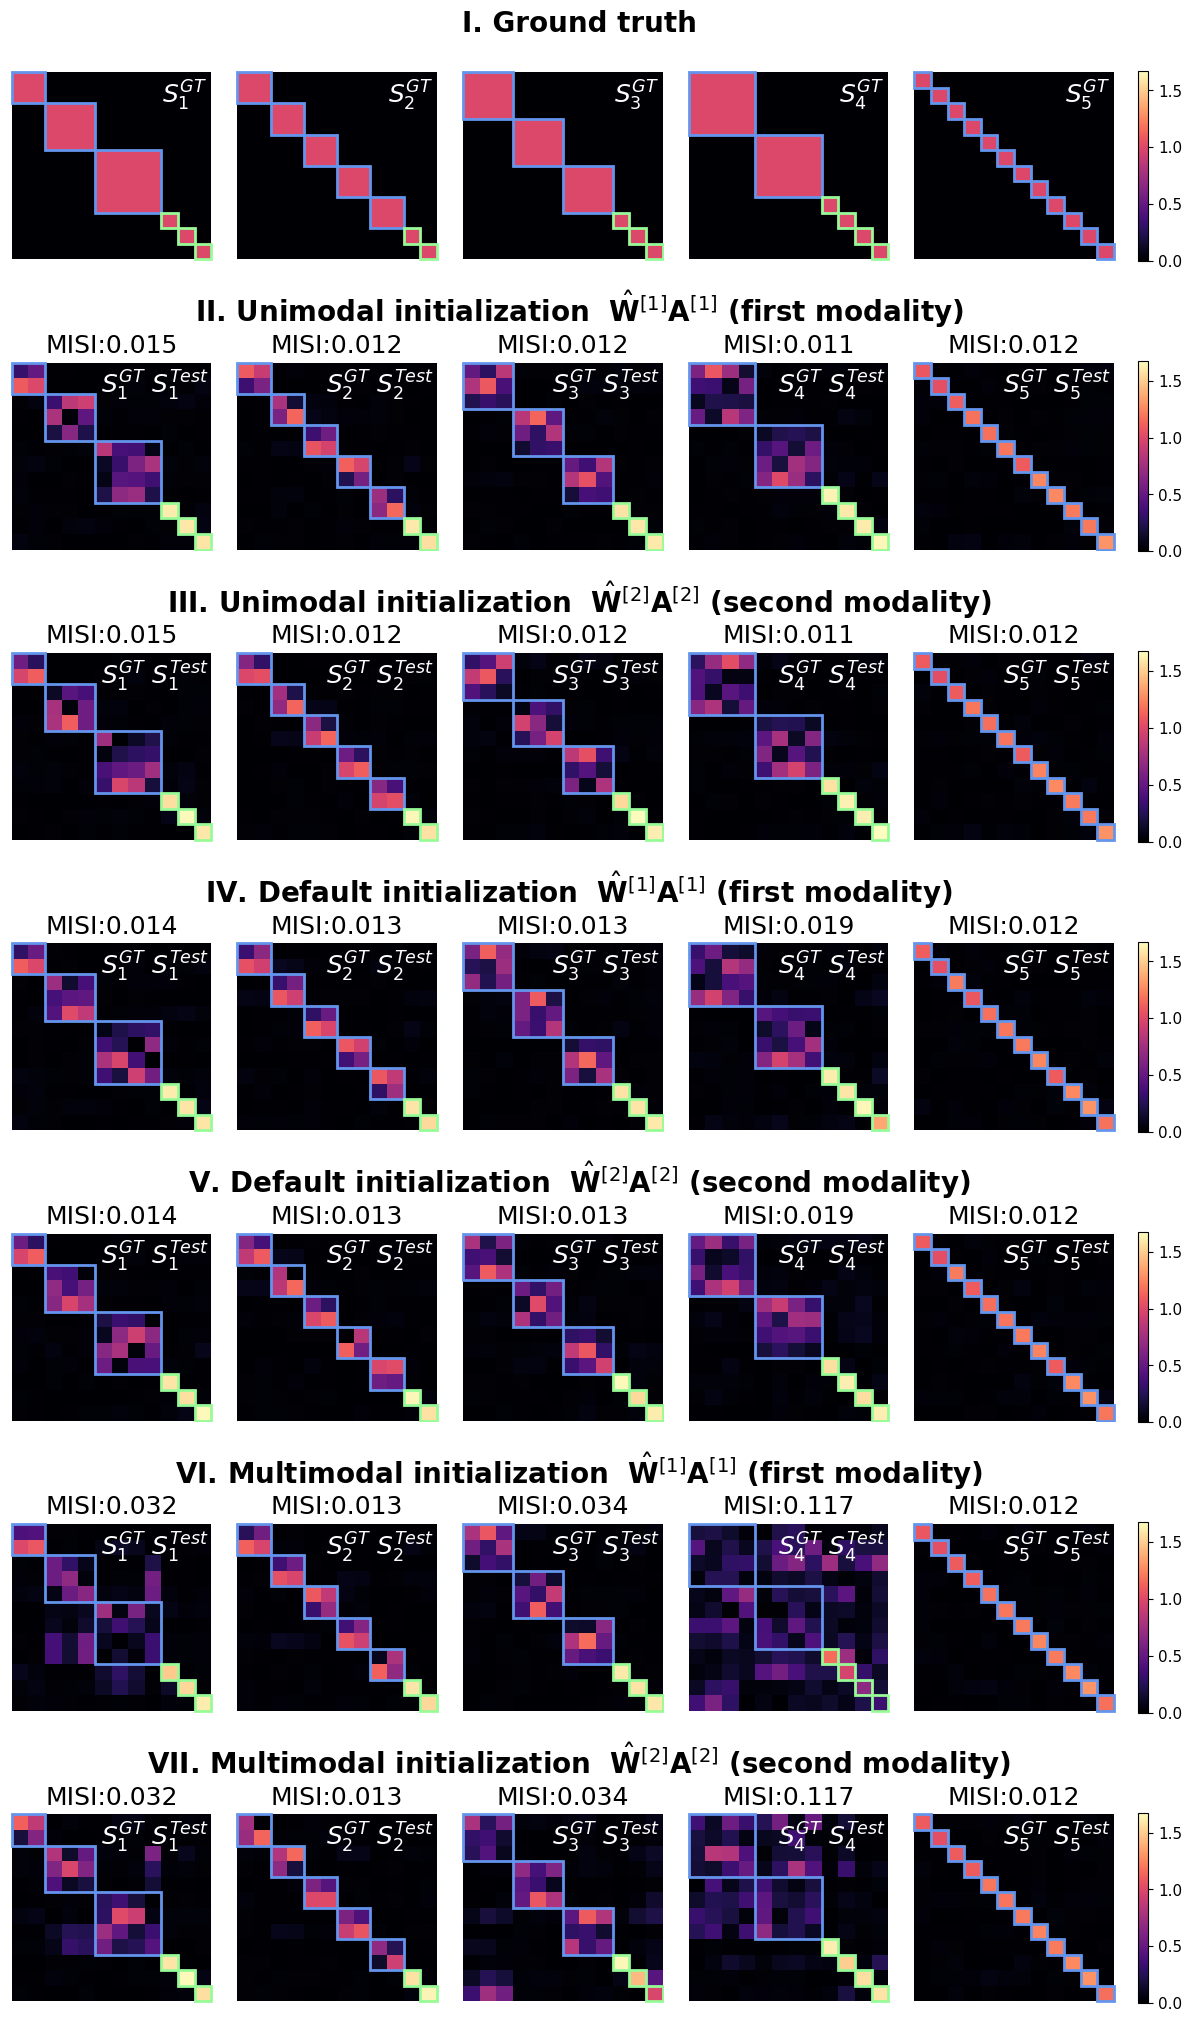

In [ ]:
corrabsmax = np.max(np.abs(corr))

wf_list = ["I. Ground truth", \
           "II. Unimodal initialization  ${\\hat{\\mathbf{W}}}^{[1]}{\\mathbf{A}}^{[1]}$ (first modality)", \
           "III. Unimodal initialization  ${\\hat{\\mathbf{W}}}^{[2]}{\\mathbf{A}}^{[2]}$ (second modality)", \
           "IV. Default initialization  ${\\hat{\\mathbf{W}}}^{[1]}{\\mathbf{A}}^{[1]}$ (first modality)", \
           "V. Default initialization  ${\\hat{\\mathbf{W}}}^{[2]}{\\mathbf{A}}^{[2]}$ (second modality)", \
           "VI. Multimodal initialization  ${\\hat{\\mathbf{W}}}^{[1]}{\\mathbf{A}}^{[1]}$ (first modality)",\
           "VII. Multimodal initialization  ${\\hat{\\mathbf{W}}}^{[2]}{\\mathbf{A}}^{[2]}$ (second modality)"]

n_row = 7
fig, axes = plt.subplots(n_row, num_ss + 1, figsize = (2.4 * num_ss, 2.9 * n_row), gridspec_kw = {'width_ratios': [1, 1, 1, 1, 1, 0.05]})

for i in range(num_ss):
    ax = axes[0,i]
    sns.heatmap(s_list[i],cmap="magma",vmin=0,vmax=corrabsmax,ax=ax,cbar=False)
    ax.text(10.4, 1.5, f"$S_{i+1}^{{GT}}$", fontsize=18, color="white", ha="center", va="center")
    ax.set_xticks([])
    ax.set_yticks([])
    plot_sq(ax, i)
    ax.set_xlim(-0.1, 12.1)
    ax.set_ylim(12.1, -0.1)

    for j in range(1, n_row):
        ax = axes[j,i]
        abscorr = np.abs(corr_sorted[i,j-1])
        sns.heatmap(abscorr,cmap="magma",vmin=0,vmax=corrabsmax,ax=ax,cbar=False)
        ax.set_title(f"MISI:{misi[(j-1)//2,i,i]:.3f}", fontsize=18)
        ax.text(8.6, 1.5, f"$S_{i+1}^{{GT}}$ $S_{i+1}^{{Test}}$", fontsize=18, color="white", ha="center", va="center")
        ax.set_xticks([])
        ax.set_yticks([])
        plot_sq(ax, i)
        ax.set_xlim(-0.1, 12.1)
        ax.set_ylim(12.1, -0.1)

norm = mpl.colors.Normalize(vmin=0, vmax=corrabsmax)
sm = mpl.cm.ScalarMappable(cmap="magma", norm=norm)
for i in range(n_row):
    ax = fig.add_subplot(n_row, 1, i+1)
    ax.set_title(wf_list[i], fontsize=20, fontweight='bold', pad=28)
    ax.axis('off')
    cbar = fig.colorbar(sm, cax=axes[i, 5])
    cbar.ax.tick_params(labelsize=11)

plt.tight_layout(pad=1, h_pad=0, w_pad=1)
plt.savefig(f"figures/simulation_absWA.pdf")